<a href="https://colab.research.google.com/github/EgemenYapucu/DataScienceExercises/blob/main/Midterm_2.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

BIL 366 Data Mining: Midterm-2

Egemen Yapucu 18120205027

In [ ]:
import pandas as pd
import numpy as np
from scipy.spatial import distance
from sklearn.metrics.pairwise import cosine_similarity
from sklearn.metrics.pairwise import euclidean_distances
import matplotlib.pyplot as plt

url = 'https://drive.google.com/file/d/18gyHbx6rfogq3yQ-GR9COjcGgyYlCnBZ/view?usp=sharing'
url2020 = 'https://drive.google.com/uc?id=' + url.split('/')[-2]
url = 'https://drive.google.com/file/d/1Eg8Lffm49bc-bGFkv_4ddrQw8U8WE6P4/view?usp=sharing'
url2021 = 'https://drive.google.com/uc?id=' + url.split('/')[-2]

df20 = pd.read_csv(url2020)

df20sample1 = df20.iloc[0:300,8:15].dropna()
df20sample2 = df20.iloc[0:400,8:15].dropna()
df20sample3 = df20.iloc[0:500,8:15].dropna()
df20sample4 = df20.iloc[0:600,8:15].dropna()

df21 = pd.read_csv(url2021)

1.Data framede içerisinde data olmayan (tüm sütun null), sütunları çıkarınız.

In [ ]:
df20 = df20.drop('metro_area',axis=1)
df20 = df20.drop('census_fips_code', axis=1)
df20.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 167657 entries, 0 to 167656
Data columns (total 13 columns):
 #   Column                                              Non-Null Count   Dtype  
---  ------                                              --------------   -----  
 0   country_region_code                                 167657 non-null  object 
 1   country_region                                      167657 non-null  object 
 2   sub_region_1                                        167336 non-null  object 
 3   sub_region_2                                        141692 non-null  object 
 4   iso_3166_2_code                                     25644 non-null   object 
 5   place_id                                            167657 non-null  object 
 6   date                                                167657 non-null  object 
 7   retail_and_recreation_percent_change_from_baseline  101865 non-null  float64
 8   grocery_and_pharmacy_percent_change_from_baseline   106104 non-n

In [ ]:
df21 = df21.drop('metro_area',axis=1)
df21 = df21.drop('census_fips_code', axis=1)
df21.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 158430 entries, 0 to 158429
Data columns (total 13 columns):
 #   Column                                              Non-Null Count   Dtype  
---  ------                                              --------------   -----  
 0   country_region_code                                 158430 non-null  object 
 1   country_region                                      158430 non-null  object 
 2   sub_region_1                                        158152 non-null  object 
 3   sub_region_2                                        135654 non-null  object 
 4   iso_3166_2_code                                     22498 non-null   object 
 5   place_id                                            158430 non-null  object 
 6   date                                                158430 non-null  object 
 7   retail_and_recreation_percent_change_from_baseline  91170 non-null   float64
 8   grocery_and_pharmacy_percent_change_from_baseline   92489 non-nu

2. Mahalanobis distance distributiondan uzaklığı ölçtüğü için outlier belirlenmesinde kullanılabilir.2020 ve 2021 her iki datayıda aylara göre gruplandırdıktan sonra her bir satır ile data arasındaki Mahalanobis distance'ı hesaplayarak yeni bir sütun olarak ekleyiniz ve buradaki en büyük elemanın outlier olduğunu 2020 ve 2021 yılları için ayrı ayrı gösteriniz.

In [ ]:
df20 = df20.iloc[:,6:13].dropna()
df20.index = pd.to_datetime(df20.date, format='%Y/%m/%d')
df20 = df20.groupby(by = [df20.index.month]).mean()

df21 = df21.iloc[:,6:13].dropna()
df21.index = pd.to_datetime(df21.date, format='%Y/%m/%d')
df21 = df21.groupby(by = [df21.index.month]).mean()

In [ ]:
def mahalanobis(d = None, data = None, cov = None):
    d_mu = d - np.mean(data)
    if not cov :
        cov = np.cov(data.values.T)
    inv_covmat = np.linalg.inv(cov)
    left_term = np.dot(d_mu, inv_covmat)
    mahal = np.dot(left_term, d_mu.T)
    return mahal.diagonal()

df20['Mahalanobis'] = mahalanobis(df20,df20)
df21['Mahalanobis'] = mahalanobis(df21,df21)
df20.info()
df21.info()

<class 'pandas.core.frame.DataFrame'>
Int64Index: 11 entries, 2 to 12
Data columns (total 7 columns):
 #   Column                                              Non-Null Count  Dtype  
---  ------                                              --------------  -----  
 0   retail_and_recreation_percent_change_from_baseline  11 non-null     float64
 1   grocery_and_pharmacy_percent_change_from_baseline   11 non-null     float64
 2   parks_percent_change_from_baseline                  11 non-null     float64
 3   transit_stations_percent_change_from_baseline       11 non-null     float64
 4   workplaces_percent_change_from_baseline             11 non-null     float64
 5   residential_percent_change_from_baseline            11 non-null     float64
 6   Mahalanobis                                         11 non-null     float64
dtypes: float64(7)
memory usage: 704.0 bytes
<class 'pandas.core.frame.DataFrame'>
Int64Index: 10 entries, 1 to 10
Data columns (total 7 columns):
 #   Column           

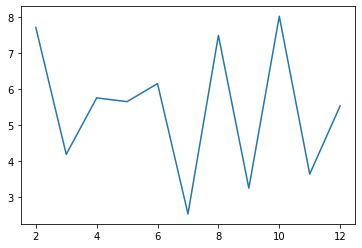

In [ ]:
plt.plot(df20.index, df20['Mahalanobis'])

Değerlerden gördüğümüz üzere distance en yüksek 10. aydadır outlier olma durumu kesindir. 2. ve 8. aylarda bu distance değerine yakındır bu noktalarda da outlier oluşabilir.

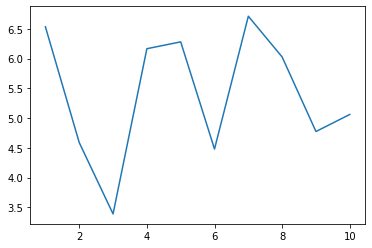

In [ ]:
plt.plot(df21.index, df21['Mahalanobis'])

Değerlerden gördüğümüz üzere distance en yüksek 7. aydadır outlier olma durumu kesindir. 1. 5. ve 4. aylarda bu distance değerine yakındır bu noktalarda da outlier oluşabilir.

3. 2020 ve 2021 datalarını aylara göre grupladıktan sonra en az iki adet fark/benzerlik ölçümü kullanarak 2020 ve 2021 datalarının 9-14 sütun verilerinin aynı aylarda birbirlerine ne oranda benzediğini bulunuz.

In [ ]:
similar1 = abs(cosine_similarity(df20, df21))
print(similar1)
similarity = similar1.mean()
print('Similarity = ', similarity)

[[0.29257626 0.22840655 0.00852846 0.13524974 0.20530072 0.33777587
  0.29345998 0.34062536 0.36153159 0.3750196 ]
 [0.9665663  0.95564168 0.80795804 0.91611577 0.95630145 0.12029314
  0.38358657 0.43303864 0.47244836 0.49315303]
 [0.99025993 0.93884425 0.71450963 0.85944433 0.91052526 0.32858287
  0.5632693  0.61263079 0.63647598 0.64867892]
 [0.98878408 0.96158246 0.77945144 0.90443897 0.94926077 0.2129773
  0.46671954 0.51677645 0.54302871 0.55879697]
 [0.37589395 0.49412544 0.63812046 0.60094897 0.62324303 0.65726238
  0.4924314  0.44755761 0.35625513 0.29963474]
 [0.06334179 0.06400142 0.27048325 0.19696419 0.22865097 0.80907632
  0.7890916  0.74997126 0.63409856 0.56480506]
 [0.04015368 0.06802144 0.23131021 0.18731641 0.23760371 0.76153607
  0.76845375 0.7195609  0.58463916 0.5084473 ]
 [0.19924634 0.3171387  0.47568956 0.43164456 0.46733574 0.72067954
  0.62529178 0.57804188 0.46417946 0.3964962 ]
 [0.20830856 0.36281261 0.58713418 0.50614648 0.50134659 0.81185564
  0.6654188  

Cosine benzerliği üzerinden ay için benzerlik oranlarından oluşan dataframe ve benzerlik oranı

In [ ]:
similar2 = euclidean_distances(df20,df21)
print(similar2)
similar2mean = similar2.mean()
similarity = 1/(1+similar2mean)
print('Euclidean Similarity = ', similarity)

[[ 87.49765701  68.46847856  45.71157749  62.47809752  74.04244836
   58.22475199 108.78243907  96.11768741  81.38890676  73.93995955]
 [ 48.06961153  30.98430121  25.46516832  29.4946799   36.64580242
   74.98620044 130.36846021 120.24621156 107.41830508 100.99759874]
 [ 36.29476791  60.13274814  90.09033237  71.79533661  59.72233159
  147.8320325  201.49453725 193.93672423 182.50413802 176.75123659]
 [ 20.18345968  40.02973155  69.0544713   50.66491984  38.03077477
  125.60407836 179.46091517 171.83153822 160.59189083 155.07718103]
 [ 78.06465009  57.86413637  39.2697889   48.78296893  54.68247854
   47.05492985  97.87179891  89.60842382  81.92384009  78.67910204]
 [105.44461244  85.40645193  64.65737606  76.05321334  81.51729633
   37.92059587  74.12498199  67.66588188  66.5075318   66.73263809]
 [108.04573479  89.23078748  70.85624803  80.46461159  84.4104583
   44.6995703   74.29583089  69.70588957  71.4582056   72.64757288]
 [ 86.57439934  66.60165353  47.09680449  57.80418741  6

Öklid uzaklığını kullanarak elde edilmiş uzaklık matrisi ve burdan hesaplanmış Öklid benzerliği.

4. 2020 datasından (50-1000) aralığında farklı büyüklüklerde samplelar oluşturarak aylık mean değerlerin ortalama ne kadar değiştiğini grafikle gösteriniz.

In [ ]:
df20sample1.index = pd.to_datetime(df20sample1.date, format='%Y/%m/%d')
df20sample1 = df20sample1.groupby(by = [df20sample1.index.month]).mean()

df20sample2.index = pd.to_datetime(df20sample2.date, format='%Y/%m/%d')
df20sample2 = df20sample2.groupby(by = [df20sample2.index.month]).mean()

df20sample3.index = pd.to_datetime(df20sample3.date, format='%Y/%m/%d')
df20sample3 = df20sample3.groupby(by = [df20sample3.index.month]).mean()

df20sample4.index = pd.to_datetime(df20sample4.date, format='%Y/%m/%d')
df20sample4 = df20sample4.groupby(by = [df20sample4.index.month]).mean()

df20 = df20.iloc[:,0:6]

In [ ]:
d1 = abs(df20sample1 - df20)
d1.info()
a = d1.mean()
print(a)
smp1failure = a.mean()
print(smp1failure)

<class 'pandas.core.frame.DataFrame'>
Int64Index: 11 entries, 2 to 12
Data columns (total 6 columns):
 #   Column                                              Non-Null Count  Dtype  
---  ------                                              --------------  -----  
 0   retail_and_recreation_percent_change_from_baseline  11 non-null     float64
 1   grocery_and_pharmacy_percent_change_from_baseline   11 non-null     float64
 2   parks_percent_change_from_baseline                  11 non-null     float64
 3   transit_stations_percent_change_from_baseline       11 non-null     float64
 4   workplaces_percent_change_from_baseline             11 non-null     float64
 5   residential_percent_change_from_baseline            11 non-null     float64
dtypes: float64(6)
memory usage: 616.0 bytes
retail_and_recreation_percent_change_from_baseline    3.688309
grocery_and_pharmacy_percent_change_from_baseline     2.107438
parks_percent_change_from_baseline                    4.338877
transit_stations

In [ ]:
d2 = abs(df20sample2 - df20)
d2.info()
b = d2.mean()
print(b)
smp2failure = b.mean()
print(smp2failure)

<class 'pandas.core.frame.DataFrame'>
Int64Index: 11 entries, 2 to 12
Data columns (total 6 columns):
 #   Column                                              Non-Null Count  Dtype  
---  ------                                              --------------  -----  
 0   retail_and_recreation_percent_change_from_baseline  11 non-null     float64
 1   grocery_and_pharmacy_percent_change_from_baseline   11 non-null     float64
 2   parks_percent_change_from_baseline                  11 non-null     float64
 3   transit_stations_percent_change_from_baseline       11 non-null     float64
 4   workplaces_percent_change_from_baseline             11 non-null     float64
 5   residential_percent_change_from_baseline            11 non-null     float64
dtypes: float64(6)
memory usage: 616.0 bytes
retail_and_recreation_percent_change_from_baseline    3.805478
grocery_and_pharmacy_percent_change_from_baseline     2.384323
parks_percent_change_from_baseline                    4.661569
transit_stations

In [ ]:
d3 = abs(df20sample3 - df20)
d3.info()
c = d3.mean()
print(c)
smp3failure = c.mean()
print(smp3failure)

<class 'pandas.core.frame.DataFrame'>
Int64Index: 11 entries, 2 to 12
Data columns (total 6 columns):
 #   Column                                              Non-Null Count  Dtype  
---  ------                                              --------------  -----  
 0   retail_and_recreation_percent_change_from_baseline  11 non-null     float64
 1   grocery_and_pharmacy_percent_change_from_baseline   11 non-null     float64
 2   parks_percent_change_from_baseline                  11 non-null     float64
 3   transit_stations_percent_change_from_baseline       11 non-null     float64
 4   workplaces_percent_change_from_baseline             11 non-null     float64
 5   residential_percent_change_from_baseline            11 non-null     float64
dtypes: float64(6)
memory usage: 616.0 bytes
retail_and_recreation_percent_change_from_baseline    2.965756
grocery_and_pharmacy_percent_change_from_baseline     2.151013
parks_percent_change_from_baseline                    6.218188
transit_stations

In [ ]:
d4 = abs(df20sample4 - df20)
d4.info()
d = d4.mean()
print(d)
smp4failure = d.mean()
print(smp4failure)

<class 'pandas.core.frame.DataFrame'>
Int64Index: 11 entries, 2 to 12
Data columns (total 6 columns):
 #   Column                                              Non-Null Count  Dtype  
---  ------                                              --------------  -----  
 0   retail_and_recreation_percent_change_from_baseline  11 non-null     float64
 1   grocery_and_pharmacy_percent_change_from_baseline   11 non-null     float64
 2   parks_percent_change_from_baseline                  11 non-null     float64
 3   transit_stations_percent_change_from_baseline       11 non-null     float64
 4   workplaces_percent_change_from_baseline             11 non-null     float64
 5   residential_percent_change_from_baseline            11 non-null     float64
dtypes: float64(6)
memory usage: 616.0 bytes
retail_and_recreation_percent_change_from_baseline    2.818312
grocery_and_pharmacy_percent_change_from_baseline     2.819632
parks_percent_change_from_baseline                    7.534053
transit_stations

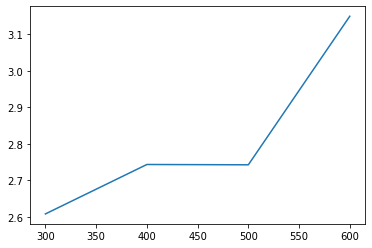

In [ ]:
x = (300,400,500,600)
y = (smp1failure,smp2failure,smp3failure,smp4failure)
plt.plot(x,y)

5. 2020 datasından her aydan (50-1000) aralığında olacak şekilde samplelar oluşturarak aylık mean değerlerin ortalama ne kadar değiştiğini grafikle gösteriniz.

In [ ]:
df20 = pd.read_csv(url2020)
df20 = df20.drop('metro_area',axis=1)
df20 = df20.drop('census_fips_code', axis=1)
df20 = df20.iloc[:,6:13].dropna()
df20.date = pd.to_datetime(df20.date, format='%Y/%m/%d')
df20.sort_values(by=['date'], inplace=True, ascending=False)
df20 = df20.reset_index(drop=True)

dfsample1 = df20.iloc[0:50,:]
dfsample1 = dfsample1.append(df20.iloc[6811:6861,:])
dfsample1 = dfsample1.append(df20.iloc[13438:13488,:])
dfsample1 = dfsample1.append(df20.iloc[20021:20071,:])
dfsample1 = dfsample1.append(df20.iloc[24426:24476,:])
dfsample1 = dfsample1.append(df20.iloc[27996:28046,:])
dfsample1 = dfsample1.append(df20.iloc[34247:34297,:])
dfsample1 = dfsample1.append(df20.iloc[40486:40536,:])
dfsample1 = dfsample1.append(df20.iloc[46563:46613,:])
dfsample1 = dfsample1.append(df20.iloc[52432:52482,:])
dfsample1 = dfsample1.append(df20.iloc[59105:59155,:])

dfsample2 = df20.iloc[0:100,:]
dfsample2 = dfsample2.append(df20.iloc[6811:6911,:])
dfsample2 = dfsample2.append(df20.iloc[13438:13538,:])
dfsample2 = dfsample2.append(df20.iloc[20021:20121,:])
dfsample2 = dfsample2.append(df20.iloc[24426:24526,:])
dfsample2 = dfsample2.append(df20.iloc[27996:28096,:])
dfsample2 = dfsample2.append(df20.iloc[34247:34347,:])
dfsample2 = dfsample2.append(df20.iloc[40486:40586,:])
dfsample2 = dfsample2.append(df20.iloc[46563:46663,:])
dfsample2 = dfsample2.append(df20.iloc[52432:52532,:])
dfsample2 = dfsample2.append(df20.iloc[59105:59205,:])

dfsample3 = df20.iloc[0:200,:]
dfsample3 = dfsample3.append(df20.iloc[6811:7011,:])
dfsample3 = dfsample3.append(df20.iloc[13438:13638,:])
dfsample3 = dfsample3.append(df20.iloc[20021:20221,:])
dfsample3 = dfsample3.append(df20.iloc[24426:24626,:])
dfsample3 = dfsample3.append(df20.iloc[27996:28196,:])
dfsample3 = dfsample3.append(df20.iloc[34247:34447,:])
dfsample3 = dfsample3.append(df20.iloc[40486:40686,:])
dfsample3 = dfsample3.append(df20.iloc[46563:46763,:])
dfsample3 = dfsample3.append(df20.iloc[52432:52632,:])
dfsample3 = dfsample3.append(df20.iloc[59105:59305,:])

dfsample4 = df20.iloc[0:300,:]
dfsample4 = dfsample4.append(df20.iloc[6811:7111,:])
dfsample4 = dfsample4.append(df20.iloc[13438:13738,:])
dfsample4 = dfsample4.append(df20.iloc[20021:20321,:])
dfsample4 = dfsample4.append(df20.iloc[24426:24726,:])
dfsample4 = dfsample4.append(df20.iloc[27996:28296,:])
dfsample4 = dfsample4.append(df20.iloc[34247:34547,:])
dfsample4 = dfsample4.append(df20.iloc[40486:40786,:])
dfsample4 = dfsample4.append(df20.iloc[46563:46863,:])
dfsample4 = dfsample4.append(df20.iloc[52432:52732,:])
dfsample4 = dfsample4.append(df20.iloc[59105:59405,:])

In [ ]:
df20.index = pd.to_datetime(df20.date, format='%Y/%m/%d')
df20 = df20.groupby(by = [df20.index.month]).mean()

dfsample1.index = pd.to_datetime(dfsample1.date, format='%Y/%m/%d')
dfsample1 = dfsample1.groupby(by = [dfsample1.index.month]).mean()



dfsample2.index = pd.to_datetime(dfsample2.date, format='%Y/%m/%d')
dfsample2 = dfsample2.groupby(by = [dfsample2.index.month]).mean()

dfsample3.index = pd.to_datetime(dfsample3.date, format='%Y/%m/%d')
dfsample3 = dfsample3.groupby(by = [dfsample3.index.month]).mean()

dfsample4.index = pd.to_datetime(dfsample4.date, format='%Y/%m/%d')
dfsample4 = dfsample4.groupby(by = [dfsample4.index.month]).mean()


<class 'pandas.core.frame.DataFrame'>
Int64Index: 11 entries, 2 to 12
Data columns (total 6 columns):
 #   Column                                              Non-Null Count  Dtype  
---  ------                                              --------------  -----  
 0   retail_and_recreation_percent_change_from_baseline  11 non-null     float64
 1   grocery_and_pharmacy_percent_change_from_baseline   11 non-null     float64
 2   parks_percent_change_from_baseline                  11 non-null     float64
 3   transit_stations_percent_change_from_baseline       11 non-null     float64
 4   workplaces_percent_change_from_baseline             11 non-null     float64
 5   residential_percent_change_from_baseline            11 non-null     float64
dtypes: float64(6)
memory usage: 616.0 bytes
retail_and_recreation_percent_change_from_baseline    15.415315
grocery_and_pharmacy_percent_change_from_baseline     21.338761
parks_percent_change_from_baseline                    22.660145
transit_stati

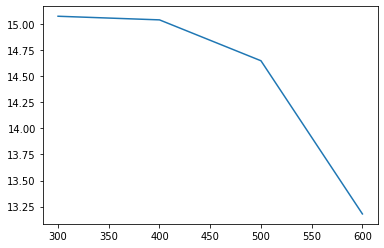

In [ ]:
df1 = abs(dfsample1 - df20)
df1.info()
a = df1.mean()
print(a)
smp1failure = a.mean()
print(smp1failure)

df2 = abs(dfsample2 - df20)
df2.info()
b = df2.mean()
print(b)
smp2failure = b.mean()
print(smp2failure)

df3 = abs(dfsample3 - df20)
df3.info()
c = df3.mean()
print(c)
smp3failure = c.mean()
print(smp3failure)

df4 = abs(dfsample4 - df20)
df4.info()
d = df4.mean()
print(d)
smp4failure = d.mean()
print(smp4failure)

x = (300,400,500,600)
y = (smp1failure,smp2failure,smp3failure,smp4failure)
plt.plot(x,y)
